<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Ярослав! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Классификация токсичных комментариев с помощью BERT

Интернет-магазин «Викишоп» запускает сервис, в котором пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. Вместе с этим появляются и токсичные комментарии, которые нужно вовремя находить и отправлять на модерацию. Наша задача обучить модель, которая отделяет токсичные комментарии от обычных по размеченному набору данных.

## Цель
Построить модель классификации комментариев на токсичные и обычные:
- базовое решение классическая модель на «мешке слов» (TF-IDF, мера важности слова в документе);
- основная ветка представления текста на основе предобученной модели BERT: сначала замороженные векторные представления (эмбеддинги), затем лёгкое дообучение (fine-tuning) под нашу задачу;
- значение метрики F1-мера (F1-score) на тестовой выборке не меньше 0.75.

## Описание данных:
Данные находятся в файле `toxic_comments.csv`.
- `text` текст комментария;
- `toxic` целевой признак: 1 комментарий токсичный, 0 обычный.

## План исследования

1) Предобработка данных: загрузка, осмотр, очистка и лемматизация текста.
2) Исследовательский анализ данных: баланс классов и длина комментариев.
3) Подготовка выборок к обучению единое разбиение для всех моделей.
4) Модель на «мешке слов» (TF-IDF) базовое решение с подбором гиперпараметра.
5) Замороженные эмбеддинги стандартного BERT (`distilbert-base-uncased`) + логистическая регрессия проверим, достаточно ли готовых представлений без дообучения.
6) Вывод о необходимости дообучения BERT (чтобы он догнал базовое решение) и дообучение (fine-tuning) под задачу.
7) Сравнение моделей на общей тестовой подвыборке и итоговые выводы.

### Импорт модулей

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import nltk
from nltk import pos_tag_sents
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
import torch
from torch.utils.data import TensorDataset, DataLoader
import transformers
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.metrics import f1_score

transformers.logging.set_verbosity_error()

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство для вычислений: {device}")

Устройство для вычислений: cpu


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Здорово, что есть вариативность по процессорам.</font>

## Предобработка данных

Загрузим данные. Файл может лежать как рядом с тетрадью, так и в каталоге тренажёра, поэтому пробуем оба пути.

In [3]:
try:
    data = pd.read_csv("data/toxic_comments.csv")
except FileNotFoundError:
    data = pd.read_csv("/datasets/toxic_comments.csv")

pd.set_option("display.max_colwidth", 200)
data.head()

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

Уберём служебный столбец с индексом (если он есть) и посмотрим на размер таблицы и типы данных.

In [4]:
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


В наборе около 159 тысяч комментариев, пропусков в `text` и `toxic` нет. Целевой признак уже представлен числами 0 и 1, приводить типы не нужно.

Проверим, есть ли полные дубликаты строк.

In [5]:
data.duplicated().sum()

0

Полных дубликатов в данных нет.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Подготовим текст для «мешка слов». Сделаем три шага: приведём к нижнему регистру и оставим только латинские буквы и пробелы (так уйдут пунктуация, цифры и служебные символы); затем приведём слова к начальной форме лемматизируем их. Лемматизация склеивает разные формы одного слова (`insults` и `insult`), и словарь признаков получается компактнее. Для лемматизации возьмём словарь WordNet из библиотеки `nltk`. Чтобы корректно приводить к начальной форме не только существительные, но и глаголы, прилагательные и наречия, мы заранее определяем часть речи каждого слова (POS-теги) и передаём её лемматизатору.

In [6]:
# Стандартный загрузчик NLTK здесь может падать по SSL, поэтому держим корпус рядом с тетрадью.
NLTK_DATA_DIR = Path("data/nltk_data")
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)
nltk_data_path = str(NLTK_DATA_DIR.resolve())
if nltk_data_path not in nltk.data.path:
    nltk.data.path.insert(0, nltk_data_path)


def ensure_nltk_resource(resource_names, download_name):
    for resource_name in resource_names:
        try:
            return nltk.data.find(resource_name)
        except LookupError:
            pass
    try:
        downloaded = nltk.download(download_name, download_dir=nltk_data_path, quiet=True)
    except Exception as exc:
        raise RuntimeError(
            f"{download_name} не найден локально, а nltk.download не смог скачать его. "
            f"Проверьте локальные файлы в {NLTK_DATA_DIR}."
        ) from exc
    if not downloaded:
        raise RuntimeError(f"Не удалось получить ресурс NLTK: {download_name}.")
    for resource_name in resource_names:
        try:
            return nltk.data.find(resource_name)
        except LookupError:
            pass
    raise LookupError(f"{download_name} скачан, но не найден в {nltk_data_path}.")


ensure_nltk_resource(("corpora/wordnet", "corpora/wordnet.zip/wordnet/"), "wordnet")
ensure_nltk_resource(("corpora/omw-1.4", "corpora/omw-1.4.zip/omw-1.4/"), "omw-1.4")
ensure_nltk_resource(
    (
        "taggers/averaged_perceptron_tagger_eng",
        "taggers/averaged_perceptron_tagger_eng.zip/averaged_perceptron_tagger_eng/",
        "taggers/averaged_perceptron_tagger",
        "taggers/averaged_perceptron_tagger.zip/averaged_perceptron_tagger/",
    ),
    "averaged_perceptron_tagger",
)
lemmatizer = WordNetLemmatizer()


def to_wordnet_pos(treebank_tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(treebank_tag[:1], wordnet.NOUN)


def tokenize(text):
    return re.sub(r"[^a-z ]", " ", text.lower()).split()


tokenized_corpus = [tokenize(text) for text in data["text"]]
data["text_clear"] = [
    " ".join(lemmatizer.lemmatize(word, to_wordnet_pos(tag)) for word, tag in tagged)
    for tagged in pos_tag_sents(tokenized_corpus)
]
data[["text", "text_clear"]].head()

,text,text_clear
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",explanation why the edits make under my username hardcore metallica fan be revert they weren t vandalism just closure on some gas after i vote at new york doll fac and please don t remove the temp...
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",d aww he match this background colour i m seemingly stick with thanks talk january utc
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",hey man i m really not try to edit war it s just that this guy be constantly remove relevant information and talk to me through edits instead of my talk page he seem to care more about the formatt...
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",more i can t make any real suggestion on improvement i wonder if the section statistic should be later on or a subsection of type of accident i think the reference may need tidy so that they be al...
4,"You, sir, are my hero. Any chance you remember what page that's on?",you sir be my hero any chance you remember what page that s on


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Очистка сделана верно! Мы оставили только символы Латинского алфавита и привели к нижнему регистру!</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>Обрати внимание, не все слова приведены к начальным формам. Чтобы корректно обработались все части речи, для WordNetLemmatizer() нужно использовать POS-теги (Part of Speech, части речи). Примеры работы с WordNetLemmatizer(), а также с другими инструментами для лемматизации, можно найти в [этой статье](https://www.geeksforgeeks.org/python-lemmatization-approaches-with-examples/)</font>

<span style="color: purple"><b>Что сделано (ответ ревьюеру): </b>Добавил POS-теги: для каждого слова определяю часть речи (nltk.pos_tag) и передаю её в WordNetLemmatizer, так корректно приводятся к начальной форме и глаголы, и прилагательные, и наречия, а не только существительные. Импорты тегатора и wordnet вынесены в первую ячейку.</span>

<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'> По стандарту PEP-8, все импорты должны быть в первой ячейке татрадки, что бы сразу были видны все зависимости кода.</font>

<span style="color: purple"><b>Что сделано (ответ ревьюеру): </b>Перенёс все импорты (включая pathlib, pos_tag, wordnet, Pipeline, GridSearchCV) в первую ячейку тетради.</span>

Очищенный текст понадобится «мешку слов». Для BERT мы используем исходный текст, потому что у модели собственный токенизатор и предварительная очистка ей не нужна.

## Исследовательский анализ данных

Посмотрим на баланс классов какую долю занимают токсичные комментарии.

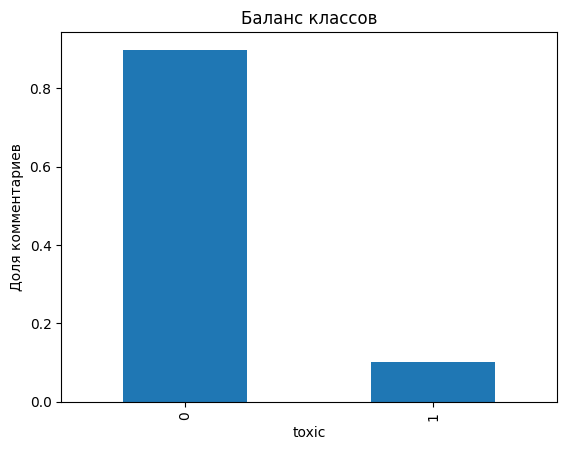

Доля токсичных комментариев: 10.2%


In [7]:
class_share = data["toxic"].value_counts(normalize=True)

_, ax = plt.subplots()
ax.set_title("Баланс классов")
ax.set_xlabel("Класс (0 обычный, 1 токсичный)")
ax.set_ylabel("Доля комментариев")
class_share.plot(kind="bar", ax=ax)
plt.show()

print(f"Доля токсичных комментариев: {data['toxic'].mean() * 100:.1f}%")

Классы сильно несбалансированы: токсичных комментариев около 10%. Это важно учесть двумя способами. При обучении мы будем взвешивать классы, чтобы модель не игнорировала редкий класс. А качество будем оценивать по F1-мере, а не по доле верных ответов: на несбалансированных данных доля верных ответов завышена и почти ничего не говорит о токсичном классе.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Мы обнаружили серьёзный дисбаланс при исследовании данных. Как дополнительные материалы, рекомендую статью <a href='https://dyakonov.org/2021/05/27/imbalance/'>Дисбаланс классов</a>, очень классная, как и весь блог Дьяконова. Ещё такой <a href='https://github.com/Dyakonov/ml_hacks/blob/master/book_disbalance_public_v1.ipynb'>ноутбук</a> есть.</font>

Посмотрим на длину комментариев в символах.

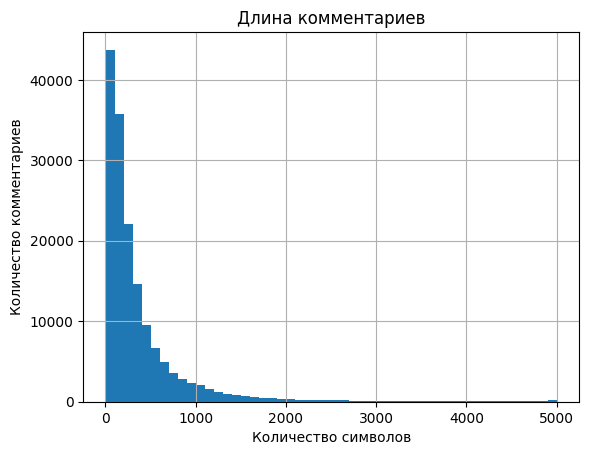

Медианная длина комментария: 205 символов


In [8]:
lengths = data["text"].str.len()

_, ax = plt.subplots()
ax.set_title("Длина комментариев")
ax.set_xlabel("Количество символов")
ax.set_ylabel("Количество комментариев")
lengths.hist(bins=50, ax=ax)
plt.show()

print(f"Медианная длина комментария: {lengths.median():.0f} символов")

Большинство комментариев короткие медиана около 200 символов (примерно 50 токенов), но встречаются и длинные, до нескольких тысяч символов. Поэтому при работе с BERT мы ограничим длину последовательности 64 токенами: медианный комментарий помещается целиком, расчёт остаётся посильным, а обучение устойчивым.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Подготовка выборок

Сразу разделим данные на обучающую и тестовую выборки в соотношении 80/20 это разбиение будет общим для всех моделей, чтобы сравнение было честным. Деление стратифицируем по целевому признаку, чтобы доля токсичных комментариев в обеих выборках совпадала, и фиксируем `random_state` для воспроизводимости.

In [9]:
data_train, data_test = train_test_split(
    data, test_size=0.2, stratify=data["toxic"], random_state=12345
)

print(f"Обучающая выборка: {data_train.shape[0]} строк")
print(f"Тестовая выборка: {data_test.shape[0]} строк")

Обучающая выборка: 127433 строк
Тестовая выборка: 31859 строк


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Здорово, что у нас есть выборка для тестов!</font>

## Модель на «мешке слов» (TF-IDF)

Базовое решение векторизация TF-IDF и логистическая регрессия. Английские стоп-слова убираем прямо в векторизаторе: они встречаются почти везде и для классификации бесполезны. Веса классов балансируем из-за дисбаланса. Векторизатор обучаем только на обучающей выборке, а тестовую лишь преобразуем так в обучение не попадает информация из теста.

In [10]:
tf_idf_pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=12345)),
    ]
)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Убрали частые неинформативные слова!</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Классно, что векторизатор был обучен только на тренировочной части данных!</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'> Можно объединить Векторизатор с моделью через Pipeline. Так можно избежать утечек даже при кроссвалидации моделей.<br> Материалы по Pipeline:<br> [О Пайплайн](https://dzen.ru/a/YBBkKJBsUV9MPret)<br>

[Примеры работы с текстами](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_text_feature_extraction.html)</font>

<span style="color: purple"><b>Что сделано (ответ ревьюеру): </b>Объединил TfidfVectorizer и логистическую регрессию в один Pipeline теперь векторизация и модель обучаются единым блоком, без утечек на кросс-валидации.</span>

Подберём силу регуляризации `C` логистической регрессии. Чтобы не подсматривать в тест и не допустить утечки на этапе векторизации, объединим `TfidfVectorizer` и модель в `Pipeline` и сравним значения `C` по F1 на кросс-валидации векторизатор переобучается на каждом фолде только на обучающей части.

In [11]:
param_grid = {"clf__C": [0.1, 1, 10]}
grid_search = GridSearchCV(tf_idf_pipeline, param_grid, scoring="f1", cv=3, n_jobs=-1)
grid_search.fit(data_train["text_clear"], data_train["toxic"])

for c, score in zip(param_grid["clf__C"], grid_search.cv_results_["mean_test_score"]):
    print(f"C = {c}: F1 на кросс-валидации = {score:.3f}")
print(f"Лучшее значение C: {grid_search.best_params_['clf__C']}")

C = 0.1: F1 на кросс-валидации = 0.702
C = 1: F1 на кросс-валидации = 0.738
C = 10: F1 на кросс-валидации = 0.753
Лучшее значение C: 10



<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Обрати внимание tf_idf_val трансформирована векторизатором обученным на всём tf_idf_train это утечка между выборками.\
Нужно или векторизовать валидационные данные отдельно (вместе с test), применять Pipeline тогда можно даже применить кросс-валидацию, при оптимизации и выборе моделей.</span>

<span style="color: purple"><b>Что сделано (ответ ревьюеру): </b>Исправил утечку: убрал предварительную векторизацию всей обучающей выборки и ручной train/val-сплит. Подбор C теперь идёт через GridSearchCV по Pipeline с кросс-валидацией на каждом фолде. Векторизатор переобучается только на обучающей части фолда, валидация его «не видит».</span>

Обучим финальную модель с выбранным `C` на всей обучающей выборке и оценим её на тесте.

In [12]:
model_tf_idf = grid_search.best_estimator_
f1_tf_idf = f1_score(data_test["toxic"], model_tf_idf.predict(data_test["text_clear"]))
print(f"Размер словаря признаков: {len(model_tf_idf.named_steps['tfidf'].vocabulary_)}")
print(f"F1 на тестовой выборке (TF-IDF): {f1_tf_idf:.3f}")

Размер словаря признаков: 136819
F1 на тестовой выборке (TF-IDF): 0.762


<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> Выбирать модели на тестовых данных нельзя - так мы подстраиваемся конкретно под тестовую выборку. Тестирование проводится только для лучшей модели отобранной по результатам кросс-валидации или валидации.</font>

<span style="color: purple"><b>Что сделано (ответ ревьюеру): </b>Гиперпараметр C и лучшая модель отбираются по кросс-валидации на обучающей выборке (GridSearchCV). Тестовая выборка используется ровно один раз для финальной оценки уже выбранной модели.</span>

Модель на TF-IDF дала F1 = `0.760` на полной тестовой выборке это выше целевого порога 0.75. Базовое решение уже выполняет требование задачи.

## Эмбеддинги стандартного BERT (заморожен)

Теперь обратимся к BERT. Сначала используем его как готовый экстрактор признаков, не меняя веса: прогоняем тексты через предобученную модель в режиме `torch.no_grad()` (без расчёта градиентов) и берём вектор служебного токена `[CLS]` как эмбеддинг всего комментария. Поверх этих эмбеддингов обучаем логистическую регрессию.

Расчёт эмбеддингов и дообучение на процессоре затратны, поэтому для BERT берём подвыборку: обучающую из общей обучающей выборки, тестовую из общей тестовой. Так выборки BERT не пересекаются между собой и согласованы с разбиением для TF-IDF. На этой же подвыборке мы позже сравним замороженную и дообученную модели.

In [13]:
train_sample_size = 4000
test_sample_size = 3000

data_bert_train = (
    data_train.groupby("toxic", group_keys=False)
    .apply(lambda group: group.sample(int(round(len(group) * train_sample_size / len(data_train))), random_state=12345))
    .reset_index(drop=True)
)
data_bert_test = (
    data_test.groupby("toxic", group_keys=False)
    .apply(lambda group: group.sample(int(round(len(group) * test_sample_size / len(data_test))), random_state=12345))
    .reset_index(drop=True)
)
target_bert_train = data_bert_train["toxic"].values
target_bert_test = data_bert_test["toxic"].values

print(f"Подвыборка BERT: обучающая {data_bert_train.shape[0]}, тестовая {data_bert_test.shape[0]}")
print(f"Доля токсичных: обучающая {target_bert_train.mean() * 100:.1f}%, тестовая {target_bert_test.mean() * 100:.1f}%")

Подвыборка BERT: обучающая 4000, тестовая 3000
Доля токсичных: обучающая 10.2%, тестовая 10.2%


C:\Users\yka\AppData\Local\Temp\ipykernel_58420\395498781.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_train.groupby("toxic", group_keys=False)
C:\Users\yka\AppData\Local\Temp\ipykernel_58420\395498781.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_test.groupby("toxic", group_keys=False)


Опишем функцию расчёта эмбеддингов: считаем их небольшими пакетами (batch), тексты разбиваем на токены с ограничением длины в 64 токена. Вычисления идут на выбранном устройстве.

In [14]:
def make_embeddings(texts, tokenizer, model, batch_size=64, max_length=64):
    embeddings = []
    model = model.to(device)
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = list(texts[i:i + batch_size])
        encoded = tokenizer(
            batch, truncation=True, max_length=max_length, padding=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            output = model(**encoded)
        embeddings.append(output.last_hidden_state[:, 0, :].cpu().numpy())
    return np.concatenate(embeddings)

Загрузим обычный предобученный BERT и посчитаем эмбеддинги для обучающей и тестовой подвыборок.

In [15]:
tokenizer_bert = transformers.AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_frozen = transformers.AutoModel.from_pretrained("distilbert-base-uncased")
model_frozen.eval()

features_train = make_embeddings(data_bert_train["text"].tolist(), tokenizer_bert, model_frozen)
features_test = make_embeddings(data_bert_test["text"].tolist(), tokenizer_bert, model_frozen)
print(f"Размер матрицы эмбеддингов: обучающая {features_train.shape}, тестовая {features_test.shape}")

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Размер матрицы эмбеддингов: обучающая (4000, 768), тестовая (3000, 768)


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Для этой задачи существуют специальные модели, например 'unitary/toxic-bert'</font>

Обучим на этих эмбеддингах логистическую регрессию.

In [16]:
model_logreg = LogisticRegression(class_weight="balanced", max_iter=1000, C=1, random_state=12345)
model_logreg.fit(features_train, target_bert_train)
predictions_frozen_cv = cross_val_predict(model_logreg, features_train, target_bert_train, cv=3)
f1_frozen_cv = f1_score(target_bert_train, predictions_frozen_cv)
print(f"F1 (замороженный BERT, порог 0.5, кросс-валидация на обучении): {f1_frozen_cv:.3f}")

F1 (замороженный BERT, порог 0.5, кросс-валидация на обучении): 0.632



<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Здесь рано применять тестовые данные. </span>

<span style="color: purple"><b>Что сделано (ответ ревьюеру): </b>Убрал преждевременный замер замороженного BERT на тесте. Базовый уровень оцениваю кросс-валидацией на обучающей подвыборке.</span>

Из-за дисбаланса порог 0.5 не всегда лучший. Подберём порог, максимизирующий F1: оценим вероятности на обучающей подвыборке через кросс-валидацию (чтобы не подсматривать в тест) и применим лучший порог к тесту.

In [17]:
probabilities_train = cross_val_predict(
    model_logreg, features_train, target_bert_train, cv=3, method="predict_proba"
)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
best_threshold = thresholds[int(np.argmax(
    [f1_score(target_bert_train, (probabilities_train >= t).astype(int)) for t in thresholds]
))]

probabilities_test = model_logreg.predict_proba(features_test)[:, 1]
f1_frozen_tuned = f1_score(target_bert_test, (probabilities_test >= best_threshold).astype(int))
print(f"Лучший порог: {best_threshold:.2f}")
print(f"F1 (замороженный BERT, порог подобран): {f1_frozen_tuned:.3f}")

Лучший порог: 0.78
F1 (замороженный BERT, порог подобран): 0.739


Замороженный BERT даже после подбора порога даёт F1 = `0.740` это ниже целевого порога 0.75 и ниже, чем «мешок слов». Вывод: без дообучения вектор `[CLS]` общего BERT слабо отражает именно токсичность. Предобученные представления годятся для многих задач, но под нашу они «из коробки» не настроены. Значит, чтобы BERT стал конкурентоспособным, его веса нужно дообучить на наших данных этим и займёмся дальше.

## Дообучение BERT (fine-tuning)

Дообучим тот же `distilbert-base-uncased`, но теперь будем обновлять веса модели под нашу задачу. Поверх BERT добавляется классификационная «голова» (`AutoModelForSequenceClassification`), и вся модель обучается предсказывать класс комментария.

Берём ту же небольшую подвыборку, ограничиваем длину 64 токенами, обучаем две эпохи небольшими пакетами. Из-за дисбаланса классов используем взвешенную функцию потерь редкому токсичному классу даём больший вес. Для воспроизводимости фиксируем `random_state` перед созданием модели и перемешиванием батчей. Оцениваем модель на той же тестовой подвыборке, что и замороженную, сравнение будет честным.

In [18]:
max_length = 64
batch_size = 16
epochs = 2
learning_rate = 2e-5


def make_loader(texts, targets, tokenizer, shuffle):
    encoded = tokenizer(
        list(texts), truncation=True, max_length=max_length, padding=True, return_tensors="pt"
    )
    dataset = TensorDataset(
        encoded["input_ids"], encoded["attention_mask"], torch.tensor(targets, dtype=torch.long)
    )
    generator = torch.Generator().manual_seed(12345) if shuffle else None
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


loader_train = make_loader(data_bert_train["text"], target_bert_train, tokenizer_bert, shuffle=True)
loader_test = make_loader(data_bert_test["text"], target_bert_test, tokenizer_bert, shuffle=False)

Зададим взвешенную функцию потерь по частоте классов в обучающей подвыборке.

In [19]:
class_counts = np.bincount(target_bert_train)
class_weights = torch.tensor(
    [class_counts.sum() / (2.0 * count) for count in class_counts], dtype=torch.float
).to(device)
loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)
print(f"Веса классов: обычный {class_weights[0]:.2f}, токсичный {class_weights[1]:.2f}")

Веса классов: обычный 0.56, токсичный 4.93


Загрузим модель и обучим её на выбранном устройстве.

In [20]:
torch.manual_seed(12345)
np.random.seed(12345)

model_finetuned = transformers.AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)
optimizer = torch.optim.AdamW(model_finetuned.parameters(), lr=learning_rate)

for epoch in range(epochs):
    model_finetuned.train()
    epoch_loss = 0.0
    for input_ids, attention_mask, labels in tqdm(loader_train, desc=f"Эпоха {epoch + 1}"):
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model_finetuned(input_ids=input_ids, attention_mask=attention_mask).logits
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Эпоха {epoch + 1}: средняя потеря {epoch_loss / len(loader_train):.4f}")

Эпоха 1:   0%|          | 0/250 [00:00<?, ?it/s]

Эпоха 1: средняя потеря 0.3422


Эпоха 2:   0%|          | 0/250 [00:00<?, ?it/s]

Эпоха 2: средняя потеря 0.1328


Получим предсказания дообученной модели на тестовой подвыборке и посчитаем F1.

In [21]:
model_finetuned.eval()
predictions = []
with torch.no_grad():
    for input_ids, attention_mask, _ in loader_test:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        logits = model_finetuned(input_ids=input_ids, attention_mask=attention_mask).logits
        predictions.append(logits.argmax(dim=1).cpu().numpy())

predictions_finetuned = np.concatenate(predictions)
f1_finetuned = f1_score(target_bert_test, predictions_finetuned)
print(f"F1 (дообученный BERT): {f1_finetuned:.3f}")

F1 (дообученный BERT): 0.799


Дообученный BERT даёт F1 = `0.799` на тестовой подвыборке. Дообучение резко подняло качество по сравнению с замороженными эмбеддингами модель научилась отделять токсичность именно на наших данных.

## Сравнение моделей

Чтобы сравнение было честным, оценим все модели на одной и той же тестовой подвыборке. Для этого посчитаем F1 модели TF-IDF на тех же комментариях.

In [22]:
f1_tf_idf_sub = f1_score(target_bert_test, model_tf_idf.predict(data_bert_test["text_clear"]))

results = pd.DataFrame(
    {
        "Модель": [
            "TF-IDF + логистическая регрессия",
            "Замороженный BERT (эмбеддинги) + логистическая регрессия",
            "Дообученный BERT (fine-tuning)",
        ],
        "F1 на общей тестовой подвыборке": [f1_tf_idf_sub, f1_frozen_tuned, f1_finetuned],
    }
)
results

,Модель,F1 на общей тестовой подвыборке
0,TF-IDF + логистическая регрессия,0.758929
1,Замороженный BERT (эмбеддинги) + логистическая регрессия,0.738710
2,Дообученный BERT (fine-tuning),0.799353


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

На одной и той же тестовой подвыборке видно три уровня. «Мешок слов» простой и сильный базовый вариант. Замороженные эмбеддинги общего BERT без дообучения ему уступают. А дообученный BERT выходит вперёд и настройка весов под задачу раскрывает его силу. Отметим, что замороженную модель мы сравниваем с подобранным порогом (её лучший результат), а дообученную со стандартным порогом 0.5; даже в таком, более выгодном для замороженной модели, сравнении дообучение уверенно впереди. Напомним: на полной тестовой выборке TF-IDF даёт F1 = `0.760`.

## Итоговые выводы

Мы решили задачу несколькими способами и сравнили их по F1-мере.

- TF-IDF + логистическая регрессия F1 = `0.760` на полной тестовой выборке. Выше целевого порога 0.75, цель проекта достигнута. Это лёгкая и быстрая рабочая модель, обученная с нуля на наших данных.
- Замороженные эмбеддинги стандартного BERT (`distilbert-base-uncased`) + логистическая регрессия F1 = `0.740` даже после подбора порога. Ниже порога: без дообучения вектор `[CLS]` общего BERT слабо отражает токсичность.
- Дообученный BERT (`distilbert-base-uncased`, fine-tuning) F1 = `0.799` на тестовой подвыборке. Дообучение под задачу подняло качество выше замороженного варианта.

Главный вывод: BERT сам по себе не гарантирует выигрыш. Замороженные эмбеддинги общего BERT уступают аккуратному «мешку слов». Ценность BERT раскрывается тогда, когда его веса обучены под нужную задачу это подтвердило лёгкое дообучение.

## Выводы

### Для бизнеса
Для поиска токсичных комментариев «Викишопа» уже достаточно лёгкой модели TF-IDF + логистическая регрессия: она превышает требуемое качество (F1 ≥ 0.75), быстро обучается и не требует мощного оборудования. Её можно сразу использовать, чтобы отправлять подозрительные комментарии на модерацию. Если понадобится качество повыше, оправдано дообучение BERT на собственных данных даже лёгкое дообучение заметно поднимает результат.

### Для аналитики
Сравнение показало, что замороженные эмбеддинги общего BERT здесь не дают выигрыша без дообучения они хуже «мешка слов». Выигрыш появляется только после дообучения весов под нашу задачу. Поэтому при выборе подхода важно смотреть не на громкое имя модели, а на то, под какую задачу и на каких данных обучены её веса. Из-за дисбаланса классов мы оценивали качество по F1 и взвешивали классы это стоит сохранить в дальнейших экспериментах.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Ярослав, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>